In [ ]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
dokumen_asli = [
    "Sistem komputer memproses data dan menjalankan aplikasi.",
    "Jaringan komputer menghubungkan perangkat untuk berbagi data.",
    "Keamanan jaringan melindungi sistem dan data dari serangan.",
    "Aplikasi komputer membantu pengguna mengolah informasi."
]

df_dokumen = pd.DataFrame({
    "Dokumen": [f"D{i+1}" for i in range(len(dokumen_asli))],
    "Teks Asli": dokumen_asli
})
display(df_dokumen)

,Dokumen,Teks Asli
0,D1,Sistem komputer memproses data dan menjalankan...
1,D2,Jaringan komputer menghubungkan perangkat untu...
2,D3,Keamanan jaringan melindungi sistem dan data d...
3,D4,Aplikasi komputer membantu pengguna mengolah i...


In [ ]:
stopwords_id = {
    "dan", "yang", "di", "ke", "dari", "untuk", "dengan", "agar",
    "atau", "pada", "adalah", "ini", "itu", "dalam", "secara",
    "oleh", "sebagai", "serta", "dapat", "akan"
}

def preprocess_sederhana(text):
    text = text.lower()                         # Case folding
    text = re.sub(r"[^a-z\s]", " ", text)    # Cleaning tanda baca/angka
    tokens = text.split()                       # Tokenisasi
    tokens = [t for t in tokens if t not in stopwords_id]  # Stopwords removal
    return tokens

token_dokumen = [preprocess_sederhana(teks) for teks in dokumen_asli]
dokumen_bersih = [" ".join(tokens) for tokens in token_dokumen]

df_prep = pd.DataFrame({
    "Dokumen": [f"D{i+1}" for i in range(len(dokumen_asli))],
    "Token Setelah Preprocessing": [" | ".join(tokens) for tokens in token_dokumen],
    "Teks Bersih": dokumen_bersih
})
display(df_prep)

,Dokumen,Token Setelah Preprocessing,Teks Bersih
0,D1,sistem | komputer | memproses | data | menjala...,sistem komputer memproses data menjalankan apl...
1,D2,jaringan | komputer | menghubungkan | perangka...,jaringan komputer menghubungkan perangkat berb...
2,D3,keamanan | jaringan | melindungi | sistem | da...,keamanan jaringan melindungi sistem data serangan
3,D4,aplikasi | komputer | membantu | pengguna | me...,aplikasi komputer membantu pengguna mengolah i...


In [ ]:
count_vectorizer = CountVectorizer(lowercase=False, token_pattern=r"(?u)\b\w+\b")
bow_array = count_vectorizer.fit_transform(dokumen_bersih).toarray()
terms = count_vectorizer.get_feature_names_out()

df_bow = pd.DataFrame(bow_array, index=[f"D{i+1}" for i in range(len(dokumen_bersih))], columns=terms)
print("Matriks Bag-of-Words (raw count):")
display(df_bow)

Matriks Bag-of-Words (raw count):


,aplikasi,berbagi,data,informasi,jaringan,keamanan,komputer,melindungi,membantu,memproses,menghubungkan,mengolah,menjalankan,pengguna,perangkat,serangan,sistem
D1,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1
D2,0,1,1,0,1,0,1,0,0,0,1,0,0,0,1,0,0
D3,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0,1,1
D4,1,0,0,1,0,0,1,0,1,0,0,1,0,1,0,0,0


In [ ]:
N = len(dokumen_bersih)

tf_manual = bow_array.copy()
df_term = (bow_array > 0).sum(axis=0)
idf_manual = np.log(N / df_term) + 1

df_perhitungan = pd.DataFrame({
    "Term": terms,
    **{f"TF D{i+1}": tf_manual[i] for i in range(N)},
    "df": df_term,
    "IDF = ln(N/df)+1": idf_manual
})
print("Tabel TF, df, dan IDF:")
display(df_perhitungan.round(4))

tfidf_manual_array = tf_manual * idf_manual
df_tfidf_manual = pd.DataFrame(tfidf_manual_array, index=[f"D{i+1}" for i in range(N)], columns=terms)
print("Matriks TF-IDF manual (belum dinormalisasi):")
display(df_tfidf_manual.round(4))

Tabel TF, df, dan IDF:


,Term,TF D1,TF D2,TF D3,TF D4,df,IDF = ln(N/df)+1
0,aplikasi,1,0,0,1,2,1.6931
1,berbagi,0,1,0,0,1,2.3863
2,data,1,1,1,0,3,1.2877
3,informasi,0,0,0,1,1,2.3863
4,jaringan,0,1,1,0,2,1.6931
5,keamanan,0,0,1,0,1,2.3863
6,komputer,1,1,0,1,3,1.2877
7,melindungi,0,0,1,0,1,2.3863
8,membantu,0,0,0,1,1,2.3863
9,memproses,1,0,0,0,1,2.3863


Matriks TF-IDF manual (belum dinormalisasi):


,aplikasi,berbagi,data,informasi,jaringan,keamanan,komputer,melindungi,membantu,memproses,menghubungkan,mengolah,menjalankan,pengguna,perangkat,serangan,sistem
D1,1.6931,0.0000,1.2877,0.0000,0.0000,0.0000,1.2877,0.0000,0.0000,2.3863,0.0000,0.0000,2.3863,0.0000,0.0000,0.0000,1.6931
D2,0.0000,2.3863,1.2877,0.0000,1.6931,0.0000,1.2877,0.0000,0.0000,0.0000,2.3863,0.0000,0.0000,0.0000,2.3863,0.0000,0.0000
D3,0.0000,0.0000,1.2877,0.0000,1.6931,2.3863,0.0000,2.3863,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.3863,1.6931
D4,1.6931,0.0000,0.0000,2.3863,0.0000,0.0000,1.2877,0.0000,2.3863,0.0000,0.0000,2.3863,0.0000,2.3863,0.0000,0.0000,0.0000


In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    use_idf=True,
    smooth_idf=False,
    norm=None
)

tfidf_sklearn_array = tfidf_vectorizer.fit_transform(dokumen_bersih).toarray()
terms_sklearn = tfidf_vectorizer.get_feature_names_out()

df_tfidf_sklearn = pd.DataFrame(
    tfidf_sklearn_array,
    index=[f"D{i+1}" for i in range(N)],
    columns=terms_sklearn
)
print("Matriks TF-IDF dari scikit-learn:")
display(df_tfidf_sklearn.round(4))

print("Hasil manual sama dengan scikit-learn:",
      np.allclose(tfidf_manual_array, tfidf_sklearn_array))
print("Selisih absolut maksimum:",
      round(float(np.max(np.abs(tfidf_manual_array - tfidf_sklearn_array))), 10))

Matriks TF-IDF dari scikit-learn:


,aplikasi,berbagi,data,informasi,jaringan,keamanan,komputer,melindungi,membantu,memproses,menghubungkan,mengolah,menjalankan,pengguna,perangkat,serangan,sistem
D1,1.6931,0.0000,1.2877,0.0000,0.0000,0.0000,1.2877,0.0000,0.0000,2.3863,0.0000,0.0000,2.3863,0.0000,0.0000,0.0000,1.6931
D2,0.0000,2.3863,1.2877,0.0000,1.6931,0.0000,1.2877,0.0000,0.0000,0.0000,2.3863,0.0000,0.0000,0.0000,2.3863,0.0000,0.0000
D3,0.0000,0.0000,1.2877,0.0000,1.6931,2.3863,0.0000,2.3863,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.3863,1.6931
D4,1.6931,0.0000,0.0000,2.3863,0.0000,0.0000,1.2877,0.0000,2.3863,0.0000,0.0000,2.3863,0.0000,2.3863,0.0000,0.0000,0.0000


Hasil manual sama dengan scikit-learn: True
Selisih absolut maksimum: 0.0


In [ ]:
top_terms = []
for i in range(N):
    top3 = df_tfidf_sklearn.iloc[i].sort_values(ascending=False).head(3)
    top_terms.append({
        "Dokumen": f"D{i+1}",
        "Term 1": f"{top3.index[0]} ({top3.iloc[0]:.4f})" if len(top3) > 0 else "-",
        "Term 2": f"{top3.index[1]} ({top3.iloc[1]:.4f})" if len(top3) > 1 else "-",
        "Term 3": f"{top3.index[2]} ({top3.iloc[2]:.4f})" if len(top3) > 2 else "-"
    })

df_top = pd.DataFrame(top_terms)
display(df_top)

,Dokumen,Term 1,Term 2,Term 3
0,D1,menjalankan (2.3863),memproses (2.3863),aplikasi (1.6931)
1,D2,berbagi (2.3863),perangkat (2.3863),menghubungkan (2.3863)
2,D3,melindungi (2.3863),serangan (2.3863),keamanan (2.3863)
3,D4,informasi (2.3863),pengguna (2.3863),membantu (2.3863)


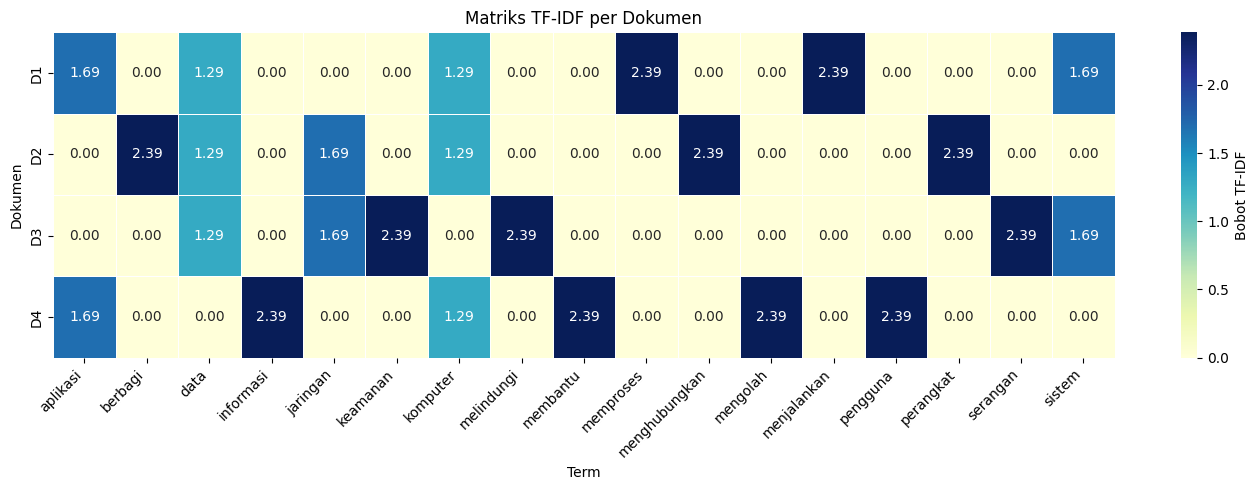

In [ ]:
plt.figure(figsize=(14, 5))
sns.heatmap(df_tfidf_sklearn, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "Bobot TF-IDF"})
plt.title("Matriks TF-IDF per Dokumen")
plt.xlabel("Term")
plt.ylabel("Dokumen")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Metode TF-IDF digunakan untuk menentukan tingkat kepentingan suatu kata dalam sebuah dokumen dibandingkan dengan dokumen lainnya. Kata yang sering muncul dalam satu dokumen akan memiliki nilai TF yang lebih besar, sedangkan kata yang jarang ditemukan pada dokumen lain akan meningkatkan nilai IDF. Hasil perhitungan tersebut menghasilkan bobot yang menunjukkan seberapa penting suatu kata dalam merepresentasikan dokumen. Dengan demikian, TF-IDF dapat membantu sistem menemukan dokumen yang memiliki keterkaitan berdasarkan kata-kata yang terkandung di dalamnya.